In [1]:
import pandas as pd
import os

# Define the file path using a raw string to handle Windows backslashes safely
# Updated to point to the new mird_benchmark_test output directory if needed
file_path = r"/home/matias/Documents/Tesis/Vision-Aided-Beamformer/data_analysis/avance2/Data/Exp_A_3.parquet"

# Define a mapping dictionary to rename processors for cleaner plotting
# You can easily edit the string values on the right side of the colon
PROCESSOR_MAP = {
    "DS": "DS",
    "NM-MVDR": "NM-MVDR",
}

# Verify if the file exists before attempting to load it
if os.path.exists(file_path):
    # Load the Parquet file into a Pandas DataFrame
    df_metrics = pd.read_parquet(file_path)

    # Apply the processor mapping to the 'processor' column right after loading
    if 'processor' in df_metrics.columns:
        df_metrics['processor'] = df_metrics['processor'].replace(PROCESSOR_MAP)



    # Identify and keep only metadata columns and metrics evaluated with the 'early' reference
    suffixes_to_drop = ('_anechoic', '_reverberant')
    cols_to_keep = [col for col in df_metrics.columns if not col.endswith(suffixes_to_drop)]
    df_metrics = df_metrics[cols_to_keep]

    # Strip the '_early' suffix from the column names for cleaner plotting later
    df_metrics.columns = [col.replace('_early', '') if col.endswith('_early') else col for col in df_metrics.columns]

    print(f"Dataset successfully loaded, filtered, and processors mapped! Shape: {df_metrics.shape}\n")

    # Display the first few rows to confirm data integrity
    display(df_metrics.head())

else:
    print(f"Error: File not found at the specified path:\n{file_path}")
    print("Please check your current working directory using 'import os; print(os.getcwd())'.")

Dataset successfully loaded, filtered, and processors mapped! Shape: (216, 92)



,processor,rt60,M,N_interferences,mismatch_pos,isir_db,mismatch_gain,mismatch_phase,use_wpe,error_angle_deg,...,Delta_dtln_post_SAR,Delta_tot_pipeline_SAR,Delta_tot_SINR,Delta_wpe_SINR,Delta_bf_SINR,dtln_alone_SINR,dtln_post_SINR,Delta_dtln_alone_SINR,Delta_dtln_post_SINR,Delta_tot_pipeline_SINR
0,DS,0.16,8,2,0.0,-4,0,0,False,0.0,...,-33.247820,-48.312093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NM-MVDR,0.16,8,2,0.0,-4,0,0,False,0.0,...,-1.505714,-43.337679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DS,0.16,8,2,0.0,-2,0,0,False,0.0,...,-33.228474,-48.099809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NM-MVDR,0.16,8,2,0.0,-2,0,0,False,0.0,...,-1.559411,-43.230841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DS,0.16,8,2,0.0,0,0,0,False,0.0,...,-32.668394,-47.263621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define the root directory to save all generated figures for the thesis
FIGURES_DIR = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Desarrollo/Algoritmos"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Define the Okabe-Ito color palette for colorblind accessibility
# Colors: Orange, Sky Blue, Bluish Green, Yellow, Blue, Vermilion, Reddish Purple, Black
OKABE_ITO_PALETTE = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442",
    "#0072B2", "#D55E00", "#CC79A7", "#000000"
]

def set_thesis_plot_style():
    """
    Applies global formatting rules for Matplotlib and Seaborn.
    Integrates Okabe-Ito colors and sizes appropriate for an A4 LaTeX document.
    """
    # Set the general Seaborn style and apply the new palette
    sns.set_theme(style="whitegrid", context="paper")
    sns.set_palette(sns.color_palette(OKABE_ITO_PALETTE))

    # Configure Matplotlib parameters
    plt.rcParams.update({
        # Typography: Sans-serif is recommended for charts for better readability
        # If you want to strictly match LaTeX text, change "sans-serif" to "serif"
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

        # Font sizes coordinated with an 11pt main text in LaTeX
        "font.size": 11,                 # Base font size (matches document)
        "axes.titlesize": 11,            # Subplot title size
        "axes.labelsize": 10,            # Axis labels slightly smaller than main text
        "xtick.labelsize": 9,            # Tick labels (max 2 points smaller)
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "legend.title_fontsize": 10,

        # Apply Okabe-Ito to base Matplotlib cycle (for non-Seaborn plots)
        "axes.prop_cycle": plt.cycler('color', OKABE_ITO_PALETTE),

        # Dimensions matching A4 paper with standard 2.5 cm margins
        # Text width is ~160mm (6.3 inches). Height uses the golden ratio (~3.89 inches).
        "figure.figsize": (6.3, 3.89),

        # High resolution outputs
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",         # Removes unnecessary white space around edges

        # Line and marker weights
        "lines.linewidth": 1.5,          # Slightly thicker for better visibility
        "lines.markersize": 5
    })

In [3]:
import os
import locale
import matplotlib.pyplot as plt
import seaborn as sns

# Define the root directory to save all generated figures for the thesis
FIGURES_DIR = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Desarrollo/Algoritmos"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Define the Okabe-Ito color palette for colorblind accessibility
# Colors: Orange, Sky Blue, Bluish Green, Yellow, Blue, Vermilion, Reddish Purple, Black
OKABE_ITO_PALETTE = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442",
    "#0072B2", "#D55E00", "#CC79A7", "#000000"
]

def set_thesis_plot_style():
    """
    Applies global formatting rules for Matplotlib and Seaborn.
    Integrates Okabe-Ito colors and sizes appropriate for an A4 LaTeX document,
    and sets the decimal separator to a comma for Spanish formatting.
    """
    # Attempt to set the system locale to Spanish for numeric formatting
    # This ensures a comma is used instead of a dot for decimals
    try:
        # Try Argentina locale first, then Spain as fallback
        locale.setlocale(locale.LC_NUMERIC, "es_AR.UTF-8")
    except locale.Error:
        try:
            locale.setlocale(locale.LC_NUMERIC, "es_ES.UTF-8")
        except locale.Error:
            # If neither is installed on the OS, print a warning
            print("Warning: Spanish locale not found. Decimal separator will remain a dot.")

    # Set the general Seaborn style and apply the new palette
    sns.set_theme(style="whitegrid", context="paper")
    sns.set_palette(sns.color_palette(OKABE_ITO_PALETTE))

    # Configure Matplotlib parameters
    plt.rcParams.update({
        # Enable Matplotlib to use the locale settings defined above
        "axes.formatter.use_locale": True,

        # Typography: Sans-serif is recommended for charts for better readability
        # If you want to strictly match LaTeX text, change "sans-serif" to "serif"
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

        # Font sizes coordinated with an 11pt main text in LaTeX
        "font.size": 11,                 # Base font size (matches document)
        "axes.titlesize": 11,            # Subplot title size
        "axes.labelsize": 10,            # Axis labels slightly smaller than main text
        "xtick.labelsize": 9,            # Tick labels (max 2 points smaller)
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "legend.title_fontsize": 10,

        # Apply Okabe-Ito to base Matplotlib cycle (for non-Seaborn plots)
        "axes.prop_cycle": plt.cycler('color', OKABE_ITO_PALETTE),

        # Dimensions matching A4 paper with standard 2.5 cm margins
        # Text width is ~160mm (6.3 inches). Height uses the golden ratio (~3.89 inches).
        "figure.figsize": (6.3, 3.89),

        # High resolution outputs
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",         # Removes unnecessary white space around edges

        # Line and marker weights
        "lines.linewidth": 1.5,          # Slightly thicker for better visibility
        "lines.markersize": 5
    })

/tmp/ipykernel_16900/4128487195.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16900/4128487195.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16900/4128487195.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16900/4128487195.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


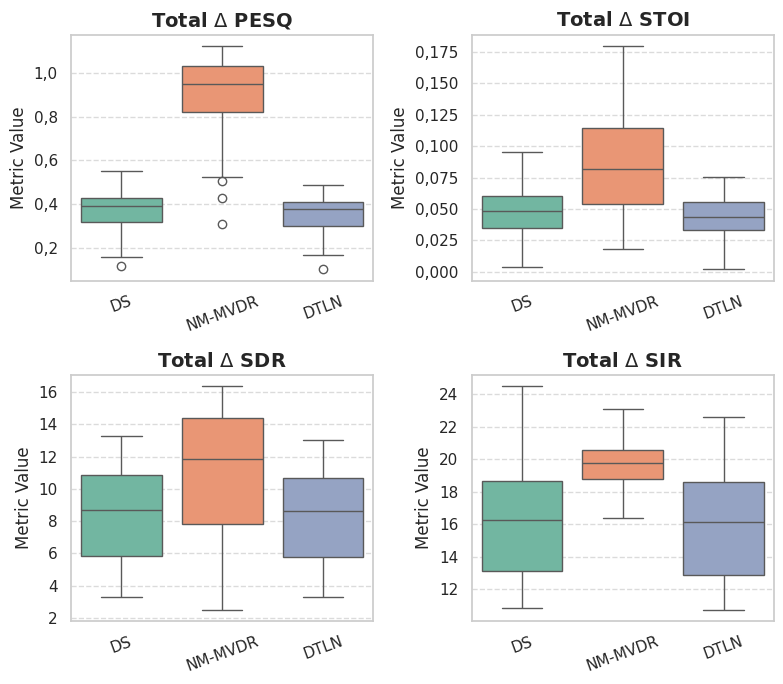

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import locale
import matplotlib.pyplot as plt

# Apply the newly generated locale
locale.setlocale(locale.LC_NUMERIC, 'es_AR.UTF-8')
plt.rcParams['axes.formatter.use_locale'] = True

# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# We will build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer + DTLN results
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        col_name = f'Delta_tot_pipeline_{metric}'
        if col_name in df_proc.columns:
            for val in df_proc[col_name].dropna():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': val
                })

# 2. Extract DTLN Alone results
# DTLN alone is computed per acoustic scene, not per processor.
# To avoid duplicating the exact same DTLN alone values for every processor
# evaluated in the same scene, we just grab them from the first processor's rows.
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_dtln_alone = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        col_name = f'Delta_dtln_alone_{metric}'
        if col_name in df_dtln_alone.columns:
            for val in df_dtln_alone[col_name].dropna():
                plot_data.append({
                    'Algorithm': 'DTLN',
                    'Metric': metric,
                    'Value': val
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten()

# Loop through the base metrics and create a boxplot for each
for i, metric in enumerate(base_metrics):

    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the boxplot with Algorithms on the X-axis and metric values on the Y-axis
    sns.boxplot(
        data=df_subset,
        x='Algorithm',
        y='Value',
        ax=axes[i],
        palette='Set2'
    )

    # Format titles and labels for clarity
    axes[i].set_title(f'Total $\Delta$ {metric}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Metric Value', fontsize=12)
    axes[i].set_xlabel('', fontsize=12)


    # Rotate the X-axis labels slightly and align them to the right for better horizontal spacing
    plt.setp(axes[i].get_xticklabels(), rotation=20, ha='center')

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust the layout so plots do not overlap
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# Define a logical order for the X-axis
algorithms_present = df_plot['Algorithm'].unique().tolist()
order = ['Entrada', 'DTLN'] + [alg for alg in algorithms_present if alg not in ['Entrada', 'DTLN']]

# Extract the 'Set2' colors into a list
set2_colors = sns.color_palette("Set2")

# Create a dictionary to map each algorithm to a specific color from 'Set2'
# Change the indices (0, 1, 2, etc.) to swap the colors around
custom_palette = {
    'Entrada': set2_colors[2],  # Assigns the 3rd color of Set2 to 'Entrada'
    'DTLN': set2_colors[1],
    "NM-DTLN": set2_colors[0]   # Assigns the 1st color of Set2 to 'NM-DTLN'
}

# Dynamically assign the remaining colors to the other algorithms
other_algorithms = [alg for alg in order if alg not in ['Entrada', 'DTLN']]
for idx, alg in enumerate(other_algorithms):
    # Use an offset (e.g., + 3) to pick different colors from the palette
    color_index = (idx + 3) % len(set2_colors)
    custom_palette[alg] = set2_colors[color_index]

# Loop through the base metrics and create a boxplot for each
for i, metric in enumerate(base_metrics):
    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the boxplot passing the dictionary to the palette parameter
    sns.boxplot(
        data=df_subset,
        x='Algorithm',
        y='Value',
        ax=axes[i],
        palette=custom_palette,
        order=order
    )

/tmp/ipykernel_16900/2414428787.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16900/2414428787.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16900/2414428787.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16900/2414428787.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


/tmp/ipykernel_16900/1621645163.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16900/1621645163.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16900/1621645163.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16900/1621645163.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


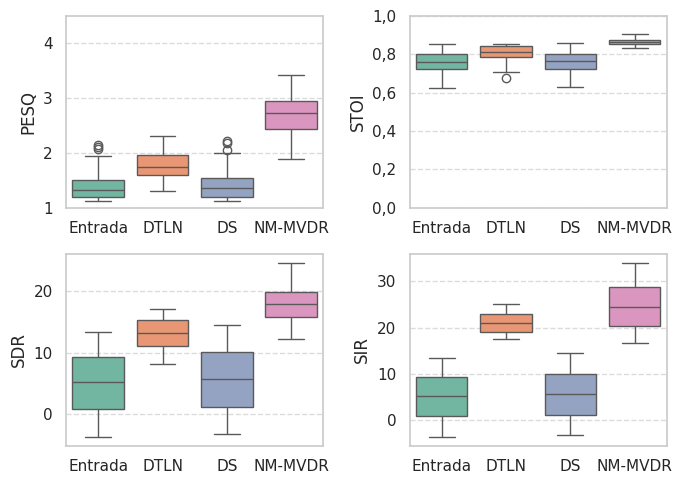

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Define a logical order for the X-axis
algorithms_present = df_plot['Algorithm'].unique().tolist()
order = ['Entrada', 'DTLN'] + [alg for alg in algorithms_present if alg not in ['Entrada', 'DTLN']]

# Extract the 'Set2' colors into a list
set2_colors = sns.color_palette("Set2")

# Create a dictionary to map each algorithm to a specific color from 'Set2'
# Change the indices (0, 1, 2, etc.) to swap the colors around
custom_palette = {
    'Entrada': set2_colors[2],  # Assigns the 3rd color of Set2 to 'Entrada'
    'DTLN': set2_colors[1],
    "NM-DTLN": set2_colors[0]   # Assigns the 1st color of Set2 to 'NM-DTLN'
}

# Dynamically assign the remaining colors to the other algorithms
other_algorithms = [alg for alg in order if alg not in ['Entrada', 'DTLN']]
for idx, alg in enumerate(other_algorithms):
    # Use an offset (e.g., + 3) to pick different colors from the palette
    color_index = (idx + 3) % len(set2_colors)
    custom_palette[alg] = set2_colors[color_index]

# Loop through the base metrics and create a boxplot for each
for i, metric in enumerate(base_metrics):
    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the boxplot passing the dictionary to the palette parameter
    sns.boxplot(
        data=df_subset,
        x='Algorithm',
        y='Value',
        ax=axes[i],
        palette=custom_palette,
        order=order
    )


# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# Build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer results
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        # Dynamically find the exact column name for the absolute output
        col_candidates = [c for c in df_proc.columns if c.startswith(f'proc_{metric}')]
        if col_candidates:
            col_name = col_candidates[0]
            for val in df_proc[col_name].dropna():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': val
                })

# 2. Extract Base (Entrada) and DTLN Alone results
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_first = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        # Extract noisy input baseline (Entrada)
        base_candidates = [c for c in df_first.columns if c.startswith(f'base_{metric}')]
        if base_candidates:
            for val in df_first[base_candidates[0]].dropna():
                plot_data.append({
                    'Algorithm': 'Entrada',
                    'Metric': metric,
                    'Value': val
                })

        # Extract DTLN Alone
        dtln_candidates = [c for c in df_first.columns if c.startswith(f'dtln_alone_{metric}')]
        if dtln_candidates:
            for val in df_first[dtln_candidates[0]].dropna():
                plot_data.append({
                    'Algorithm': 'DTLN',
                    'Metric': metric,
                    'Value': val
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Safety check to prevent KeyErrors if no columns matched
if df_plot.empty:
    raise ValueError("No data found to plot. Please verify the column names in df_metrics.")

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

# Define a logical order for the X-axis
algorithms_present = df_plot['Algorithm'].unique().tolist()
order = ['Entrada', 'DTLN'] + [alg for alg in algorithms_present if alg not in ['Entrada', 'DTLN']]

# Loop through the base metrics and create a boxplot for each
for i, metric in enumerate(base_metrics):
    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the boxplot forcing the specific X-axis order
    sns.boxplot(
        data=df_subset,
        x='Algorithm',
        y='Value',
        ax=axes[i],
        palette='Set2',
        order=order
    )

    # Format titles and labels for absolute values
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_xlabel('', fontsize=12)

    # Set specific axis limits for bounded metrics
    if metric == 'PESQ':
        axes[i].set_ylim(1.0, 4.5)
    elif metric == 'STOI':
        axes[i].set_ylim(0.0, 1.0)

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)



# Adjust the layout so plots do not overlap
plt.tight_layout()

# Save the figure as a PDF file
save_path = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/boxplot_resultados_generales.pdf"
plt.savefig(save_path, format='pdf', bbox_inches='tight')

/tmp/ipykernel_19040/2298868294.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19040/2298868294.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19040/2298868294.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19040/2298868294.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


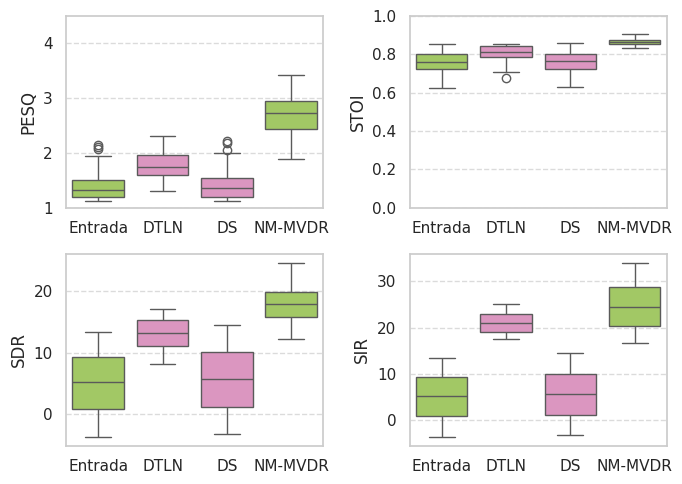

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# Build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer results
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        # Dynamically find the exact column name for the absolute output
        col_candidates = [c for c in df_proc.columns if c.startswith(f'proc_{metric}')]
        if col_candidates:
            col_name = col_candidates[0]
            for val in df_proc[col_name].dropna():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': val
                })

# 2. Extract Base (Entrada) and DTLN Alone results
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_first = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        # Extract noisy input baseline (Entrada)
        base_candidates = [c for c in df_first.columns if c.startswith(f'base_{metric}')]
        if base_candidates:
            for val in df_first[base_candidates[0]].dropna():
                plot_data.append({
                    'Algorithm': 'Entrada',
                    'Metric': metric,
                    'Value': val
                })

        # Extract DTLN Alone
        dtln_candidates = [c for c in df_first.columns if c.startswith(f'dtln_alone_{metric}')]
        if dtln_candidates:
            for val in df_first[dtln_candidates[0]].dropna():
                plot_data.append({
                    'Algorithm': 'DTLN',
                    'Metric': metric,
                    'Value': val
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Safety check to prevent KeyErrors if no columns matched
if df_plot.empty:
    raise ValueError("No data found to plot. Please verify the column names in df_metrics.")

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

# Define a logical order for the X-axis
algorithms_present = df_plot['Algorithm'].unique().tolist()
order = ['Entrada', 'DTLN'] + [alg for alg in algorithms_present if alg not in ['Entrada', 'DTLN']]

# Extract the 'Set2' colors into a list
set2_colors = sns.color_palette("Set2")

# Create a dictionary to map each algorithm to a specific color from 'Set2'
custom_palette = {
    'Entrada': set2_colors[4],
    'DTLN': set2_colors[3],
    'DS': set2_colors[2],

    'NM-MVDR': set2_colors[1]
}

# Dynamically assign the remaining colors to the other algorithms
# Added 'NM-DTLN' to the exclusion list to avoid overwriting it
other_algorithms = [alg for alg in order if alg not in ['Entrada', 'DTLN', 'NM-DTLN']]
for idx, alg in enumerate(other_algorithms):
    # Use an offset (e.g., + 3) to pick different colors from the palette
    color_index = (idx + 3) % len(set2_colors)
    custom_palette[alg] = set2_colors[color_index]

# Loop through the base metrics and create a boxplot for each
for i, metric in enumerate(base_metrics):
    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the boxplot passing the custom dictionary to the palette parameter
    sns.boxplot(
        data=df_subset,
        x='Algorithm',
        y='Value',
        ax=axes[i],
        palette=custom_palette,
        order=order
    )

    # Format titles and labels for absolute values
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_xlabel('', fontsize=12)

    # Set specific axis limits for bounded metrics
    if metric == 'PESQ':
        axes[i].set_ylim(1.0, 4.5)
    elif metric == 'STOI':
        axes[i].set_ylim(0.0, 1.0)

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust the layout so plots do not overlap
plt.tight_layout()

# Save the figure as a PDF file
save_path = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/boxplot_resultados_generales.pdf"
plt.savefig(save_path, format='pdf', bbox_inches='tight')

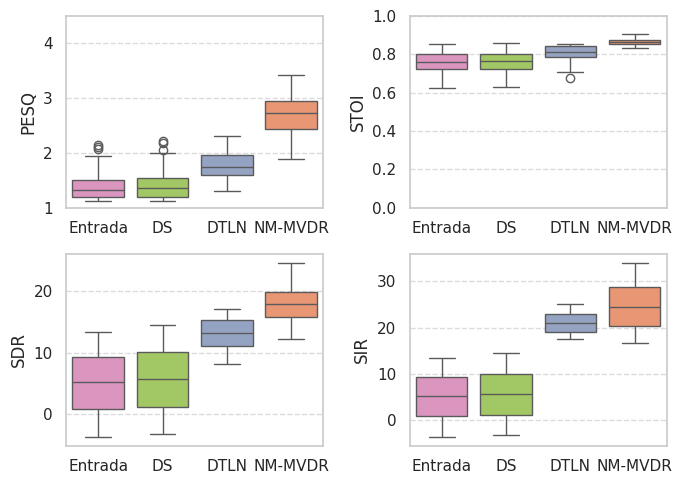

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# Build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer results
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        # Dynamically find the exact column name for the absolute output
        col_candidates = [c for c in df_proc.columns if c.startswith(f'proc_{metric}')]
        if col_candidates:
            col_name = col_candidates[0]
            for val in df_proc[col_name].dropna():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': val
                })

# 2. Extract Base (Entrada) and DTLN Alone results
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_first = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        # Extract noisy input baseline (Entrada)
        base_candidates = [c for c in df_first.columns if c.startswith(f'base_{metric}')]
        if base_candidates:
            for val in df_first[base_candidates[0]].dropna():
                plot_data.append({
                    'Algorithm': 'Entrada',
                    'Metric': metric,
                    'Value': val
                })

        # Extract DTLN Alone
        dtln_candidates = [c for c in df_first.columns if c.startswith(f'dtln_alone_{metric}')]
        if dtln_candidates:
            for val in df_first[dtln_candidates[0]].dropna():
                plot_data.append({
                    'Algorithm': 'DTLN',
                    'Metric': metric,
                    'Value': val
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Safety check to prevent KeyErrors if no columns matched
if df_plot.empty:
    raise ValueError("No data found to plot. Please verify the column names in df_metrics.")

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

# Define a logical order for the X-axis
algorithms_present = df_plot['Algorithm'].unique().tolist()
order = ['Entrada', 'DS',  'DTLN', 'NM-MVDR',]

# Extract the 'Set2' colors into a list to maintain the original pastel style
set2_colors = sns.color_palette("Set2")

# Create a dictionary to map each algorithm to the specific Set2 colors requested
custom_palette = {
    'Entrada': set2_colors[3],   # Green (Set2)
    'DS': set2_colors[4],        # Blue (Set2)
    'DTLN': set2_colors[2],      # Pink (Set2)

    'NM-MVDR': set2_colors[1]    # Orange (Set2)
}

# Dynamically assign colors to any other algorithm that might appear in the dataset
# Exclude the ones we already defined manually to prevent overwriting
defined_algs = list(custom_palette.keys())
other_algorithms = [alg for alg in order if alg not in defined_algs]

for idx, alg in enumerate(other_algorithms):
    # Assign remaining colors safely
    color_index = (idx + 5) % len(set2_colors)
    custom_palette[alg] = set2_colors[color_index]

# Loop through the base metrics and create a boxplot for each
for i, metric in enumerate(base_metrics):
    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the boxplot with the hue parameter to fix the Seaborn deprecation warning
    sns.boxplot(
        data=df_subset,
        x='Algorithm',
        y='Value',
        hue='Algorithm',    # Required in newer seaborn versions when using palette
        legend=False,       # Prevents a redundant legend from appearing
        ax=axes[i],
        palette=custom_palette,
        order=order,
        hue_order=order     # Ensures the hue matches the X-axis order
    )

    # Format titles and labels for absolute values
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_xlabel('', fontsize=12)

    # Set specific axis limits for bounded metrics
    if metric == 'PESQ':
        axes[i].set_ylim(1.0, 4.5)
    elif metric == 'STOI':
        axes[i].set_ylim(0.0, 1.0)

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust the layout so plots do not overlap
plt.tight_layout()

# Save the figure as a PDF file
save_path = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/boxplot_resultados_generales.pdf"
save_path_png = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/boxplot_resultados_generales_presentación.png"

plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.savefig(save_path_png, format='png', bbox_inches='tight', dpi=600)  # Save a high-resolution PNG version as well

/tmp/ipykernel_28416/2242468138.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_28416/2242468138.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_28416/2242468138.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_28416/2242468138.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


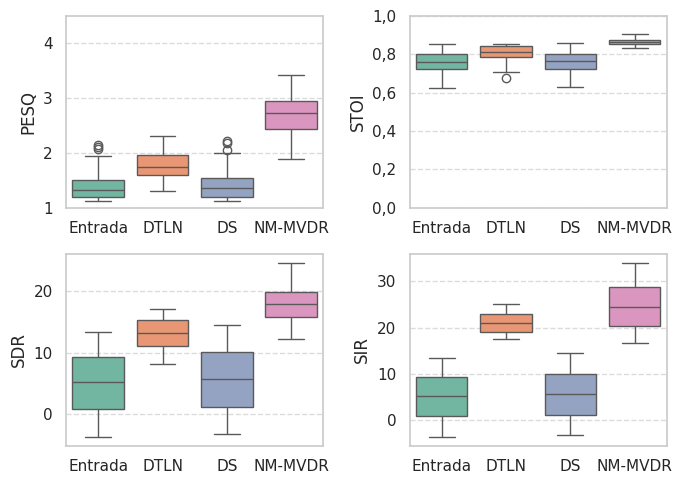

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# Build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer results
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        # Dynamically find the exact column name for the absolute output
        col_candidates = [c for c in df_proc.columns if c.startswith(f'proc_{metric}')]
        if col_candidates:
            col_name = col_candidates[0]
            for val in df_proc[col_name].dropna():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': val
                })

# 2. Extract Base (Entrada) and DTLN Alone results
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_first = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        # Extract noisy input baseline (Entrada)
        base_candidates = [c for c in df_first.columns if c.startswith(f'base_{metric}')]
        if base_candidates:
            for val in df_first[base_candidates[0]].dropna():
                plot_data.append({
                    'Algorithm': 'Entrada',
                    'Metric': metric,
                    'Value': val
                })

        # Extract DTLN Alone
        dtln_candidates = [c for c in df_first.columns if c.startswith(f'dtln_alone_{metric}')]
        if dtln_candidates:
            for val in df_first[dtln_candidates[0]].dropna():
                plot_data.append({
                    'Algorithm': 'DTLN',
                    'Metric': metric,
                    'Value': val
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Safety check to prevent KeyErrors if no columns matched
if df_plot.empty:
    raise ValueError("No data found to plot. Please verify the column names in df_metrics.")

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

# Define a logical order for the X-axis
algorithms_present = df_plot['Algorithm'].unique().tolist()
order = ['Entrada', 'DTLN'] + [alg for alg in algorithms_present if alg not in ['Entrada', 'DTLN']]

# Loop through the base metrics and create a boxplot for each
for i, metric in enumerate(base_metrics):
    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the boxplot forcing the specific X-axis order
    sns.boxplot(
        data=df_subset,
        x='Algorithm',
        y='Value',
        ax=axes[i],
        palette='Set2',
        order=order
    )

    # Format titles and labels for absolute values
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_xlabel('', fontsize=12)

    # Set specific axis limits for bounded metrics
    if metric == 'PESQ':
        axes[i].set_ylim(1.0, 4.5)
    elif metric == 'STOI':
        axes[i].set_ylim(0.0, 1.0)

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)



# Adjust the layout so plots do not overlap
plt.tight_layout()

# Save the figure as a PDF file
save_path = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/boxplot_resultados_generales_presentación.png"
plt.savefig(save_path, format='png', bbox_inches='tight', dpi = 600)

/tmp/ipykernel_28416/1930472982.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_28416/1930472982.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_28416/1930472982.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_28416/1930472982.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


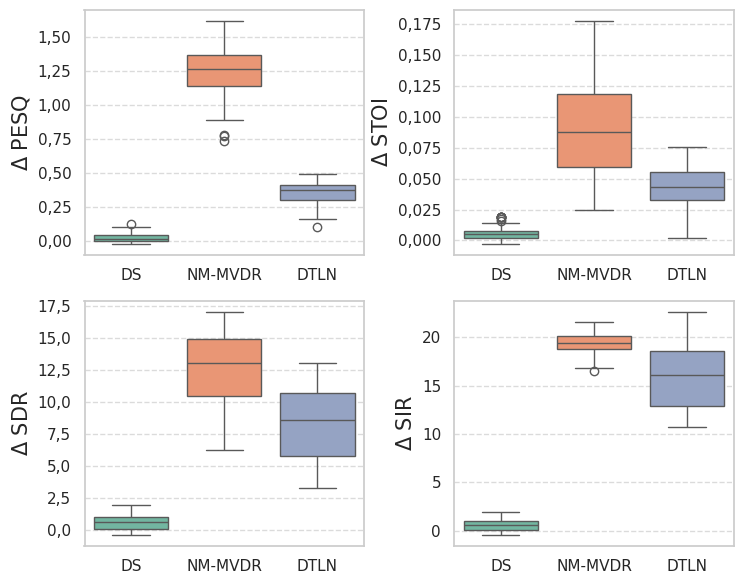

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# We will build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer-only results (No DTLN post-processing)
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        # We use 'Delta_tot_' to get the performance of the Beamformer alone compared to the baseline
        col_name = f'Delta_tot_{metric}'
        if col_name in df_proc.columns:
            for val in df_proc[col_name].dropna():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': val
                })

# 2. Extract DTLN Alone results
# We extract this only from the first processor's rows to avoid duplicating
# the same DTLN values for the same acoustic scene.
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_dtln_alone = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        col_name = f'Delta_dtln_alone_{metric}'
        if col_name in df_dtln_alone.columns:
            for val in df_dtln_alone[col_name].dropna():
                plot_data.append({
                    'Algorithm': 'DTLN',
                    'Metric': metric,
                    'Value': val
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(7.5,6))
axes = axes.flatten()

# Loop through the base metrics and create a boxplot for each
for i, metric in enumerate(base_metrics):

    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the boxplot with Algorithms on the X-axis and metric values on the Y-axis
    sns.boxplot(
        data=df_subset,
        x='Algorithm',
        y='Value',
        ax=axes[i],
        palette='Set2'
    )

    # Format titles and labels for clarity

    # Update the Y-axis to dynamically show the specific metric name
    axes[i].set_ylabel(f'$\Delta$ {metric}', fontsize=15)

    # Update the X-axis label to Spanish to match the plot title
    axes[i].set_xlabel('', fontsize=12)






    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust the layout so plots do not overlap
plt.tight_layout()

# Save the figure as a PDF file
save_path = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/boxplot_resultados_generales.pdf"
plt.savefig(save_path, format='pdf', bbox_inches='tight')

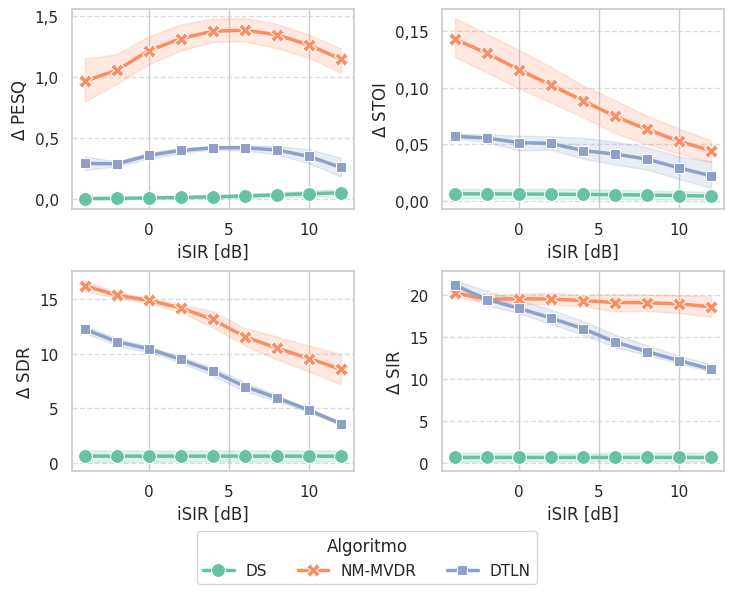

In [17]:
# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# We will build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer-only results (No DTLN post-processing)
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        col_name = f'Delta_tot_{metric}'
        if col_name in df_proc.columns:
            df_valid = df_proc.dropna(subset=[col_name])
            for idx, row in df_valid.iterrows():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': row[col_name],
                    'isir_db': row['isir_db'] # Extract isir_db instead of interferences
                })

# 2. Extract DTLN Alone results
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_dtln_alone = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        col_name = f'Delta_dtln_alone_{metric}'
        if col_name in df_dtln_alone.columns:
            df_valid = df_dtln_alone.dropna(subset=[col_name])
            for idx, row in df_valid.iterrows():
                plot_data.append({
                    'Algorithm': 'DTLN',
                    'Metric': metric,
                    'Value': row[col_name],
                    'isir_db': row['isir_db'] # Extract isir_db instead of interferences
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
# Increased bottom margin (using subplots_adjust later) to fit the legend
fig, axes = plt.subplots(2, 2, figsize=(7.5, 6))

axes = axes.flatten()

for i, metric in enumerate(base_metrics):

    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the lineplot with isir_db on the X-axis
    sns.lineplot(
        data=df_subset,
        x='isir_db',
        y='Value',
        hue='Algorithm',
        style='Algorithm',
        markers=True,
        dashes=False,
        linewidth=2.5,  # Set the thickness of the lines here
        ax=axes[i],
        palette='Set2',
        markersize=10,
    )

    # Format titles and labels for clarity
    axes[i].set_ylabel(f'$\Delta$ {metric}', fontsize=12)

    # Update X-axis label to reflect the new variable
    axes[i].set_xlabel('iSIR [dB]', fontsize=12)

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# --- CORRECTED LEGEND LOGIC ---

# 1. Retrieve handles and labels from the first subplot
handles, labels = axes[0].get_legend_handles_labels()

# 2. Remove the individual legends from ALL subplots
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# 3. Add the global legend to the figure at the bottom
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=len(df_plot['Algorithm'].unique()),
    # Make the second value (y-axis) more negative to push it further down
    # Try -0.10, -0.15, or -0.20 depending on how small you make the image
    bbox_to_anchor=(0.5, -0.001),
    title="Algoritmo"
)

# Adjust the layout so plots do not overlap
plt.tight_layout()

# Increase the bottom margin to make physical room for the lowered legend
# If bbox_to_anchor is -0.15, bottom margin usually needs to be around 0.20 or 0.25
plt.subplots_adjust(bottom=0.20)

# Save the figure as a PDF file
save_path = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/lineplot_resultados_generales_isir_db.pdf"
save_path_png = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/lineplot_resultados_generales_isir_db_presentación.png"

plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.savefig(save_path_png, format='png', bbox_inches='tight', dpi=600)


# Display the plot
plt.show()

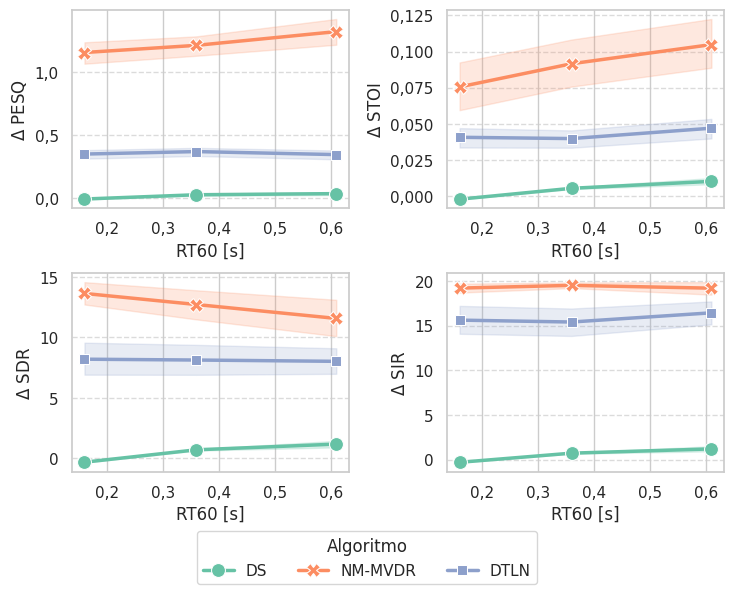

In [18]:


# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# We will build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer-only results (No DTLN post-processing)
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        col_name = f'Delta_tot_{metric}'
        if col_name in df_proc.columns:
            df_valid = df_proc.dropna(subset=[col_name])
            for idx, row in df_valid.iterrows():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': row[col_name],
                    'RT60': row['rt60'] # Extract RT60 instead of interferences
                })

# 2. Extract DTLN Alone results
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_dtln_alone = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        col_name = f'Delta_dtln_alone_{metric}'
        if col_name in df_dtln_alone.columns:
            df_valid = df_dtln_alone.dropna(subset=[col_name])
            for idx, row in df_valid.iterrows():
                plot_data.append({
                    'Algorithm': 'DTLN',
                    'Metric': metric,
                    'Value': row[col_name],
                    'RT60': row['rt60'] # Extract RT60 instead of interferences
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
# Increased bottom margin (using subplots_adjust later) to fit the legend
fig, axes = plt.subplots(2, 2, figsize=(7.5, 6))
axes = axes.flatten()

for i, metric in enumerate(base_metrics):

    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the lineplot with RT60 on the X-axis
    sns.lineplot(
        data=df_subset,
        x='RT60',
        y='Value',
        hue='Algorithm',
        style='Algorithm',
        markers=True,
        dashes=False,
        linewidth=2.5,  # Set the thickness of the lines here
        ax=axes[i],
        palette='Set2',
        markersize=10,
    )

    # Format titles and labels for clarity
    axes[i].set_ylabel(f'$\Delta$ {metric}', fontsize=12)

    # Update X-axis label to reflect the new variable
    axes[i].set_xlabel('RT60 [s]', fontsize=12)

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# --- CORRECTED LEGEND LOGIC ---

# 1. Retrieve handles and labels from the first subplot
handles, labels = axes[0].get_legend_handles_labels()

# 2. Remove the individual legends from ALL subplots
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# 3. Add the global legend to the figure at the bottom
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=len(df_plot['Algorithm'].unique()),
    # Make the second value (y-axis) more negative to push it further down
    # Try -0.10, -0.15, or -0.20 depending on how small you make the image
    bbox_to_anchor=(0.5, 0.00),
    title="Algoritmo"
)

# Adjust the layout so plots do not overlap
plt.tight_layout()

# Increase the bottom margin to make physical room for the lowered legend
# If bbox_to_anchor is -0.15, bottom margin usually needs to be around 0.20 or 0.25
plt.subplots_adjust(bottom=0.20)

# Save the figure as a PDF file with a new name reflecting the RT60 analysis
save_path = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/lineplot_resultados_generales_rt60.pdf"
save_path_png = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/lineplot_resultados_generales_rt60_presentación.png"

plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.savefig(save_path_png, format='png', bbox_inches='tight', dpi=600)

# Display the plot
plt.show()